# 01 — Data Exploration

Understand the raw Deribit option chain before building the RND on top of it. All logic lives in `src/deribit.py`; this notebook only calls it and visualizes.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

from src.deribit import get_instruments, get_option_chain
from src.storage import save_option_chain

## Available expiries
Pick a mid-dated expiry — the very front ones are often too thin for a clean smile.

In [3]:
insts = get_instruments()
expiries = sorted(insts['expiry_timestamp'].unique())
for ts in expiries:
    d = datetime.fromtimestamp(ts/1000, timezone.utc).strftime('%Y-%m-%d')
    print(f'{ts}  {d}  ({(insts.expiry_timestamp==ts).sum()} instruments)')

EXPIRY = expiries[5]  # a liquid mid-dated expiry
print('\nselected:', EXPIRY)

1781251200000  2026-06-12  (80 instruments)
1781337600000  2026-06-13  (48 instruments)
1781424000000  2026-06-14  (44 instruments)
1781510400000  2026-06-15  (40 instruments)
1781856000000  2026-06-19  (60 instruments)
1782460800000  2026-06-26  (132 instruments)
1783065600000  2026-07-03  (26 instruments)
1785484800000  2026-07-31  (114 instruments)
1787904000000  2026-08-28  (98 instruments)
1790323200000  2026-09-25  (120 instruments)
1798185600000  2026-12-25  (114 instruments)
1806048000000  2027-03-26  (102 instruments)

selected: 1782460800000


In [4]:
chain = get_option_chain(int(EXPIRY))
q = chain.quotes
print('Underlying price:', round(chain.underlying_price, 2))
print('Time to expiry (yrs):', round(chain.time_to_expiry, 4))
print('Strikes (cleaned):', len(q))
print('Strike range:', q.strike.min(), '-', q.strike.max())
print('Calls / Puts:', (q.option_type=='call').sum(), '/', (q.option_type=='put').sum())
q.head()

Underlying price: 62918.74
Time to expiry (yrs): 0.0403
Strikes (cleaned): 49
Strike range: 40000.0 - 105000.0
Calls / Puts: 31 / 18


,instrument_name,strike,option_type,bid_iv,ask_iv,mid_iv,best_bid_price,best_ask_price,mid_price,open_interest,delta
0,BTC-26JUN26-40000-P,40000.0,put,0.8073,0.9064,0.85685,0.0001,0.0003,12.583510,3706.8,-0.00406
1,BTC-26JUN26-45000-P,45000.0,put,0.7540,0.7851,0.76955,0.0006,0.0008,44.042285,4256.2,-0.01225
2,BTC-26JUN26-50000-P,50000.0,put,0.6481,0.6672,0.65765,0.0018,0.0021,122.689222,3794.8,-0.03547
3,BTC-26JUN26-52000-P,52000.0,put,0.6070,0.6207,0.61385,0.0028,0.0031,185.606773,999.4,-0.05422
4,BTC-26JUN26-55000-C,55000.0,call,0.4548,0.6046,0.52970,0.1285,0.1335,8242.199050,237.1,0.89657


## IV smile — calls vs puts
IV is already in decimal form (the `0.5413 == 54.13%` normalization happens in `deribit.py`).

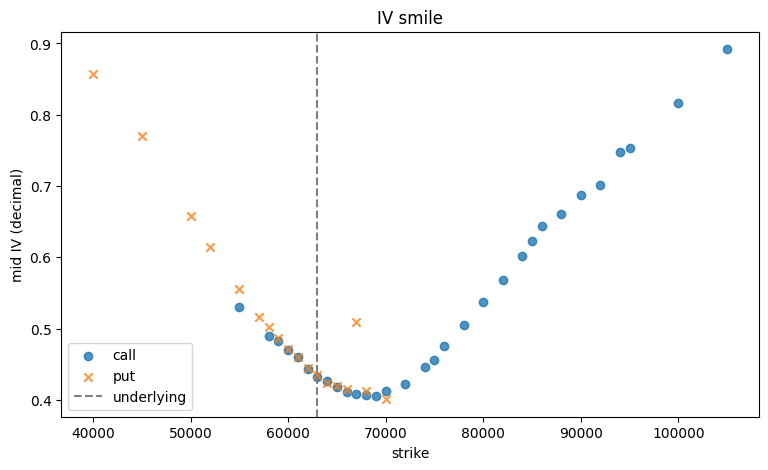

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for kind, marker in [('call', 'o'), ('put', 'x')]:
    sub = q[q.option_type == kind]
    ax.scatter(sub.strike, sub.mid_iv, label=kind, marker=marker, alpha=0.8)
ax.axvline(chain.underlying_price, color='grey', ls='--', label='underlying')
ax.set_xlabel('strike'); ax.set_ylabel('mid IV (decimal)'); ax.set_title('IV smile')
ax.legend(); plt.show()

## Bid-ask spread in IV terms
Where the spread widens, quotes are thin — these strikes are the least trustworthy inputs to the smile fit.

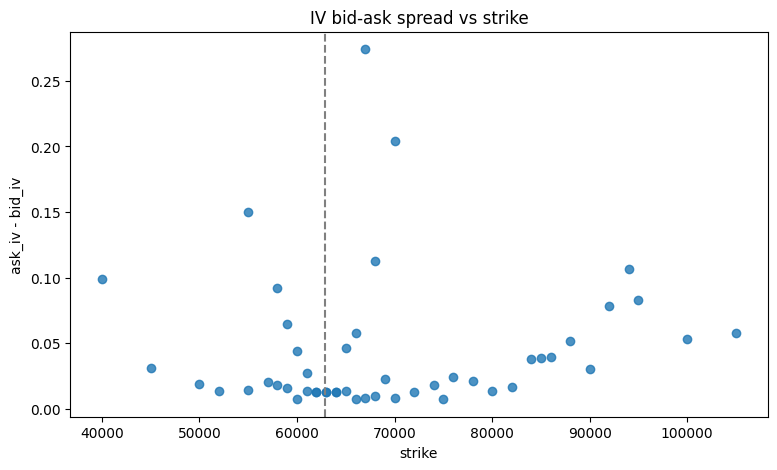

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(q.strike, q.ask_iv - q.bid_iv, alpha=0.8)
ax.axvline(chain.underlying_price, color='grey', ls='--')
ax.set_xlabel('strike'); ax.set_ylabel('ask_iv - bid_iv'); ax.set_title('IV bid-ask spread vs strike')
plt.show()

In [7]:
# Snapshot this chain for reproducible downstream work (notebooks 02/03).
path = save_option_chain(chain, label='_explore')
print('saved ->', path)

saved -> data\snapshots\chains\btc_chain_20260626_1781189464_explore.parquet
